<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap07/7_3_Initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 7.3: Initialization**

This notebook explores weight initialization in deep neural networks as described in section 7.5 of the book.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

First let's define a neural network.  We'll just choose the weights and biases randomly for now

In [2]:
def init_params(K, D, sigma_sq_omega):
  # Set seed so we always get the same random numbers
  np.random.seed(0)

  # Input layer
  D_i = 1
  # Output layer
  D_o = 1

  # Make empty lists
  all_weights = [None] * (K+1)
  all_biases = [None] * (K+1)

  # Create input and output layers
  all_weights[0] = np.random.normal(size=(D, D_i))*np.sqrt(sigma_sq_omega)
  all_weights[-1] = np.random.normal(size=(D_o, D)) * np.sqrt(sigma_sq_omega)
  all_biases[0] = np.zeros((D,1))
  all_biases[-1]= np.zeros((D_o,1))

  # Create intermediate layers
  for layer in range(1,K):
    all_weights[layer] = np.random.normal(size=(D,D))*np.sqrt(sigma_sq_omega)
    all_biases[layer] = np.zeros((D,1))

  return all_weights, all_biases

In [3]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [4]:
def compute_network_output(net_input, all_weights, all_biases):

  # Retrieve number of layers
  K = len(all_weights)-1

  # We'll store the pre-activations at each layer in a list "all_f"
  # and the activations in a second list "all_h".
  all_f = [None] * (K+1)
  all_h = [None] * (K+1)

  #For convenience, we'll set
  # all_h[0] to be the input, and all_f[K] will be the output
  all_h[0] = net_input

  # Run through the layers, calculating all_f[0...K-1] and all_h[1...K]
  for layer in range(K):
      # Update preactivations and activations at this layer according to eqn 7.5
      all_f[layer] = all_biases[layer] + np.matmul(all_weights[layer], all_h[layer])
      all_h[layer+1] = ReLU(all_f[layer])

  # Compute the output from the last hidden layer
  all_f[K] = all_biases[K] + np.matmul(all_weights[K], all_h[K])

  # Retrieve the output
  net_output = all_f[K]

  return net_output, all_f, all_h

Now let's investigate how the size of the outputs vary as we change the initialization variance:


In [5]:
# Number of layers
K = 5
# Number of neurons per layer
D = 8
# Input layer
D_i = 1
# Output layer
D_o = 1
# Set variance of initial weights to 1
sigma_sq_omega = 1.0
# Initialize parameters
all_weights, all_biases = init_params(K,D,sigma_sq_omega)

n_data = 1000
data_in = np.random.normal(size=(1,n_data))
net_output, all_f, all_h = compute_network_output(data_in, all_weights, all_biases)

for layer in range(1,K+1):
  print("Layer %d, std of hidden units = %3.3f"%(layer, np.std(all_h[layer])))

Layer 1, std of hidden units = 0.811
Layer 2, std of hidden units = 1.472
Layer 3, std of hidden units = 4.547
Layer 4, std of hidden units = 8.896
Layer 5, std of hidden units = 10.106


In [6]:
# You can see that the values of the hidden units are increasing on average (the variance is across all hidden units at the layer
# and the 1000 training examples

# TODO
# Change this to 50 layers with 80 hidden units per layer
K = 50

D = 80
# TODO
# Now experiment with sigma_sq_omega to try to stop the variance of the forward computation exploding

# La teoría de inicialización de He para ReLU  nos dice que la varianza ideal es 2 dividido por el número de neuronas de la capa (D).
sigma_sq_omega = 2.0 / D

# Initialize parameters
all_weights, all_biases = init_params(K,D,sigma_sq_omega)

n_data = 1000
data_in = np.random.normal(size=(1,n_data))
net_output, all_f, all_h = compute_network_output(data_in, all_weights, all_biases)

for layer in range(1,K+1):
  print("Layer %d, std of hidden units = %3.3f"%(layer, np.std(all_h[layer])))

Layer 1, std of hidden units = 0.098
Layer 2, std of hidden units = 0.078
Layer 3, std of hidden units = 0.083
Layer 4, std of hidden units = 0.101
Layer 5, std of hidden units = 0.111
Layer 6, std of hidden units = 0.099
Layer 7, std of hidden units = 0.092
Layer 8, std of hidden units = 0.095
Layer 9, std of hidden units = 0.083
Layer 10, std of hidden units = 0.072
Layer 11, std of hidden units = 0.076
Layer 12, std of hidden units = 0.067
Layer 13, std of hidden units = 0.065
Layer 14, std of hidden units = 0.065
Layer 15, std of hidden units = 0.064
Layer 16, std of hidden units = 0.066
Layer 17, std of hidden units = 0.070
Layer 18, std of hidden units = 0.075
Layer 19, std of hidden units = 0.073
Layer 20, std of hidden units = 0.095
Layer 21, std of hidden units = 0.080
Layer 22, std of hidden units = 0.081
Layer 23, std of hidden units = 0.085
Layer 24, std of hidden units = 0.097
Layer 25, std of hidden units = 0.106
Layer 26, std of hidden units = 0.101
Layer 27, std of hidd

En la salida del experimento del pase hacia adelante podemos notar que al aplicar la nueva escala los valores de las activaciones dejaron de multiplicarse sin control y se mantuvieron estables a lo largo de todas las cincuenta capas. Esto justifica que usar el tamaño inicial correcto evita por completo que los datos exploten al avanzar por la red.


Now let's define a loss function.  We'll just use the least squares loss function. We'll also write a function to compute dloss_doutput


In [7]:
def least_squares_loss(net_output, y):
  return np.sum((net_output-y) * (net_output-y))

def d_loss_d_output(net_output, y):
    return 2*(net_output -y);

Here's the code for the backward pass

In [8]:
# We'll need the indicator function
def indicator_function(x):
  x_in = np.array(x)
  x_in[x_in>=0] = 1
  x_in[x_in<0] = 0
  return x_in

# Main backward pass routine
def backward_pass(all_weights, all_biases, all_f, all_h, y):
  # Retrieve number of layers
  K = len(all_weights) - 1

  # We'll store the derivatives dl_dweights and dl_dbiases in lists as well
  all_dl_dweights = [None] * (K+1)
  all_dl_dbiases = [None] * (K+1)
  # And we'll store the derivatives of the loss with respect to the activation and preactivations in lists
  all_dl_df = [None] * (K+1)
  all_dl_dh = [None] * (K+1)
  # Again for convenience we'll stick with the convention that all_h[0] is the net input and all_f[k] in the net output

  # Compute derivatives of net output with respect to loss
  all_dl_df[K] = np.array(d_loss_d_output(all_f[K],y))

  # Now work backwards through the network
  for layer in range(K,-1,-1):
    # Calculate the derivatives of biases at layer from all_dl_df[K]. (eq 7.13, line 1)
    all_dl_dbiases[layer] = np.array(all_dl_df[layer])
    # Calculate the derivatives of weight at layer from all_dl_df[K] and all_h[K] (eq 7.13, line 2)
    all_dl_dweights[layer] = np.matmul(all_dl_df[layer], all_h[layer].transpose())

    # Calculate the derivatives of activations from weight and derivatives of next preactivations (eq 7.13, line 3 second part)
    all_dl_dh[layer] = np.matmul(all_weights[layer].transpose(), all_dl_df[layer])
    # Calculate the derivatives of the pre-activation f with respect to activation h (eq 7.13, line 3, first part)
    if layer > 0:
      all_dl_df[layer-1] = indicator_function(all_f[layer-1]) * all_dl_dh[layer]

  return all_dl_dweights, all_dl_dbiases, all_dl_dh, all_dl_df

Now let's look at what happens to the magnitude of the gradients on the way back.

In [9]:
# Number of layers
K = 5
# Number of neurons per layer
D = 8
# Input layer
D_i = 1
# Output layer
D_o = 1
# Set variance of initial weights to 1
sigma_sq_omega = 1.0
# Initialize parameters
all_weights, all_biases = init_params(K,D,sigma_sq_omega)

# For simplicity we'll just consider the gradients of the weights and biases between the first and last hidden layer
n_data = 100
aggregate_dl_df = [None] * (K+1)
for layer in range(1,K):
  # These 3D arrays will store the gradients for every data point
  aggregate_dl_df[layer] = np.zeros((D,n_data))


# We'll have to compute the derivatives of the parameters for each data point separately
for c_data in range(n_data):
  data_in = np.random.normal(size=(1,1))
  y = np.zeros((1,1))
  net_output, all_f, all_h = compute_network_output(data_in, all_weights, all_biases)
  all_dl_dweights, all_dl_dbiases, all_dl_dh, all_dl_df = backward_pass(all_weights, all_biases, all_f, all_h, y)
  for layer in range(1,K):
    aggregate_dl_df[layer][:,c_data] = np.squeeze(all_dl_df[layer])

for layer in reversed(range(1,K)):
  print("Layer %d, std of dl_dh = %3.3f"%(layer, np.std(aggregate_dl_df[layer].ravel())))


Layer 4, std of dl_dh = 56.472
Layer 3, std of dl_dh = 109.132
Layer 2, std of dl_dh = 340.657
Layer 1, std of dl_dh = 446.654


In [10]:
# You can see that the gradients of the hidden units are increasing on average (the standard deviation is across all hidden units at the layer
# and the 100 training examples

# TODO
# Change this to 50 layers with 80 hidden units per layer
K = 50

D = 80
# TODO
# Now experiment with sigma_sq_omega to try to stop the variance of the forward computation exploding

# La teoría de inicialización de He para ReLU  nos dice que la varianza ideal es 2 dividido por el número de neuronas de la capa (D).
sigma_sq_omega = 2.0 / D

# Initialize parameters
all_weights, all_biases = init_params(K,D,sigma_sq_omega)

# For simplicity we'll just consider the gradients of the weights and biases between the first and last hidden layer
n_data = 100
aggregate_dl_df = [None] * (K+1)
for layer in range(1,K):
  # These 3D arrays will store the gradients for every data point
  aggregate_dl_df[layer] = np.zeros((D,n_data))


# We'll have to compute the derivatives of the parameters for each data point separately
for c_data in range(n_data):
  data_in = np.random.normal(size=(1,1))
  y = np.zeros((1,1))
  net_output, all_f, all_h = compute_network_output(data_in, all_weights, all_biases)
  all_dl_dweights, all_dl_dbiases, all_dl_dh, all_dl_df = backward_pass(all_weights, all_biases, all_f, all_h, y)
  for layer in range(1,K):
    aggregate_dl_df[layer][:,c_data] = np.squeeze(all_dl_df[layer])

for layer in reversed(range(1,K)):
  print("Layer %d, std of dl_dh = %3.3f"%(layer, np.std(aggregate_dl_df[layer].ravel())))

Layer 49, std of dl_dh = 0.042
Layer 48, std of dl_dh = 0.049
Layer 47, std of dl_dh = 0.054
Layer 46, std of dl_dh = 0.053
Layer 45, std of dl_dh = 0.055
Layer 44, std of dl_dh = 0.051
Layer 43, std of dl_dh = 0.046
Layer 42, std of dl_dh = 0.042
Layer 41, std of dl_dh = 0.035
Layer 40, std of dl_dh = 0.035
Layer 39, std of dl_dh = 0.032
Layer 38, std of dl_dh = 0.035
Layer 37, std of dl_dh = 0.037
Layer 36, std of dl_dh = 0.042
Layer 35, std of dl_dh = 0.041
Layer 34, std of dl_dh = 0.044
Layer 33, std of dl_dh = 0.039
Layer 32, std of dl_dh = 0.037
Layer 31, std of dl_dh = 0.038
Layer 30, std of dl_dh = 0.037
Layer 29, std of dl_dh = 0.035
Layer 28, std of dl_dh = 0.032
Layer 27, std of dl_dh = 0.029
Layer 26, std of dl_dh = 0.035
Layer 25, std of dl_dh = 0.025
Layer 24, std of dl_dh = 0.024
Layer 23, std of dl_dh = 0.028
Layer 22, std of dl_dh = 0.027
Layer 21, std of dl_dh = 0.030
Layer 20, std of dl_dh = 0.033
Layer 19, std of dl_dh = 0.027
Layer 18, std of dl_dh = 0.030
Layer 17

Ahora bien, en la salida del experimento del pase hacia atrás vi exactamente lo mismo que en el experimentos anterior pero con los gradientes. Las derivadas dejaron de crecer de forma desmedida mientras retrocedían lo que justifica que esta misma regla matemática soluciona también el problema de los gradientes explosivos logrando que la red pueda entrenarse sin fallar.


### Análisis observado


En este cuaderno comprobé que elegir bien los números iniciales de los pesos no es cosa de adivinar. Si los dejamos al azar la señal y los errores crecen sin control hasta arruinar el modelo. Para evitarlo usé la regla de $\frac{2}{D}$ siguiendo exactamente la teoría del libro. La justificación tiene bastante sentido lógico. Cuando una neurona suma sus $D$ entradas el resultado se infla demasiado por lo que debemos achicarlo dividiendo entre $D$ para que conserve su tamaño normal. El problema surge después porque la función ReLU apaga cualquier valor negativo eliminando la mitad de lo que teníamos. Para compensar ese recorte el autor explica que debemos tomar la escala anterior y multiplicarla por dos llegando así a la fórmula final. Al probar esto en el código vi que las activaciones dejaban de explotar en el viaje de ida y los gradientes se mantenían súper estables en el de regreso. Con esto confirmé en la práctica que aplicar esta teoría desde el principio es obligatorio para que la red pueda aprender.


---
# Sección de evaluación: inicialización en la red de la figura 1 y redes profundas

En las celdas anteriores vimos cómo cambian los valores al usar números aleatorios en una red con ReLU donde todas las capas intermedias tenían el mismo tamaño. Ahora vamos a resolver la pregunta de evaluación trabajando con la red exacta de la figura 1 y luego viendo qué pasa si armamos una red mucho más profunda de 20 capas.

## Implementación de la red de la figura 1

La red de la figura 1 tiene 2 entradas, una primera capa oculta con 3 neuronas, una segunda capa con 2 neuronas y una salida final. A diferencia de lo que hicimos antes con ReLU, aquí el diagrama indica que las neuronas ocultas usan la función sigmoide $\sigma(z) = 1 / (1 + e^{-z})$, mientras que la salida es lineal.

Para poder experimentar con ella, primero escribimos el código que inicializa sus matrices de pesos con las dimensiones correctas y definimos el paso hacia adelante con la sigmoide.

In [11]:
def init_figure1_network(init_type='xavier', seed=30326271):
    np.random.seed(seed)
    # topología de la figura 1: capa 0 (2 -> 3), capa 1 (3 -> 2), capa 2 (2 -> 1)
    layer_dims = [(2, 3), (3, 2), (2, 1)]
    weights = []
    biases = []
    sigmas = []
    
    for d_in, d_out in layer_dims:
        if init_type == 'he':
            # fórmula de He para ReLU: 2 / d_in
            sigma_sq = 2.0 / d_in
        elif init_type == 'xavier':
            # fórmula de Xavier para sigmoide: 2 / (d_in + d_out)
            sigma_sq = 2.0 / (d_in + d_out)
            
        sigma = np.sqrt(sigma_sq)
        sigmas.append(sigma)
        w = np.random.normal(0.0, sigma, size=(d_out, d_in))
        b = np.zeros((d_out, 1))
        weights.append(w)
        biases.append(b)
        
    return weights, biases, sigmas

def forward_figure1(x, weights, biases):
    # capa 0 con sigmoide
    f0 = biases[0] + np.matmul(weights[0], x)
    h1 = 1.0 / (1.0 + np.exp(-f0))
    
    # capa 1 con sigmoide
    f1 = biases[1] + np.matmul(weights[1], h1)
    h2 = 1.0 / (1.0 + np.exp(-f1))
    
    # capa 2 de salida lineal
    f2 = biases[2] + np.matmul(weights[2], h2)
    return f2, (f0, f1, f2), (h1, h2)

print('Funciones de la red de la figura 1 implementadas correctamente.')

Funciones de la red de la figura 1 implementadas correctamente.


Para inicializar los pesos sin que las señales se desvanezcan o exploten, en la sección 7.5 del libro UDL se busca que la varianza de las preactivaciones se preserve entre capas, es decir, que $\operatorname{Var}[f_{out}] = \operatorname{Var}[f_{in}]$.

Para una capa con $D_h$ unidades de entrada y pesos con varianza $\sigma_\Omega^2$, la varianza de la suma ponderada es $\operatorname{Var}[f] = D_h \sigma_\Omega^2 \mathbb{E}[h^2]$. En la derivación de He, se asume que la función de activación es ReLU y que sus entradas tienen media cero con distribución simétrica. Bajo este supuesto, ReLU apaga exactamente la mitad de las neuronas (los valores negativos se hacen cero) y deja pasar la otra mitad, lo que hace que $\mathbb{E}[h^2] = \frac{1}{2} \operatorname{Var}[f_{in}]$. Al sustituir esto para preservar la varianza, se tiene:
$$D_h \sigma_\Omega^2 \left(\frac{1}{2}\operatorname{Var}[f_{in}]\right) = \operatorname{Var}[f_{in}] \implies \sigma_\Omega^2 = \frac{2}{D_h}$$

Sin embargo, la red de la figura 1 utiliza activaciones sigmoides, no ReLU. La sigmoide $\sigma(z) = 1 / (1 + e^{-z})$ nunca apaga neuronas: sus valores están acotados entre 0 y 1 con una media de 0.5, no tienen media cero y se saturan con facilidad en los extremos si la entrada es grande. Por lo tanto, el supuesto de que el 50% de las entradas se anulan deja de ser válido.

Para resolver esto, Xavier analiza la función alrededor de su zona lineal central. En el paso hacia adelante se requiere una varianza de $2 / D_{\text{in}}$ para mantener la señal, mientras que en el paso hacia atrás se requiere una varianza de $2 / D_{\text{out}}$ para que los gradientes no se desvanezcan. Para satisfacer ambas direcciones al mismo tiempo, Xavier promedia las dos dimensiones usando su media armónica:
$$\sigma_\Omega^2 = \frac{2}{D_{\text{in}} + D_{\text{out}}} \implies \sigma_\Omega = \sqrt{\frac{2}{D_{\text{in}} + D_{\text{out}}}}$$

He no necesita promediar con $D_{\text{out}}$ porque para ReLU demostró que mantener la varianza hacia adelante protege de forma natural el paso hacia atrás. A continuación calculamos estos valores numéricos para cada capa de la figura 1 y los comparamos en una tabla y en un gráfico de barras.

=== Cálculo numérico de sigma_Omega para la red de la figura 1 ===
Capa                 D_in   D_out   Fórmula de He        Fórmula de Xavier   
---------------------------------------------------------------------------
Capa 0 (Omega_0)     2      3       sqrt(2/2) = 1.0000   sqrt(2/5) = 0.6325  
Capa 1 (Omega_1)     3      2       sqrt(2/3) = 0.8165   sqrt(2/5) = 0.6325  
Capa 2 (Omega_2)     2      1       sqrt(2/2) = 1.0000   sqrt(2/3) = 0.8165  


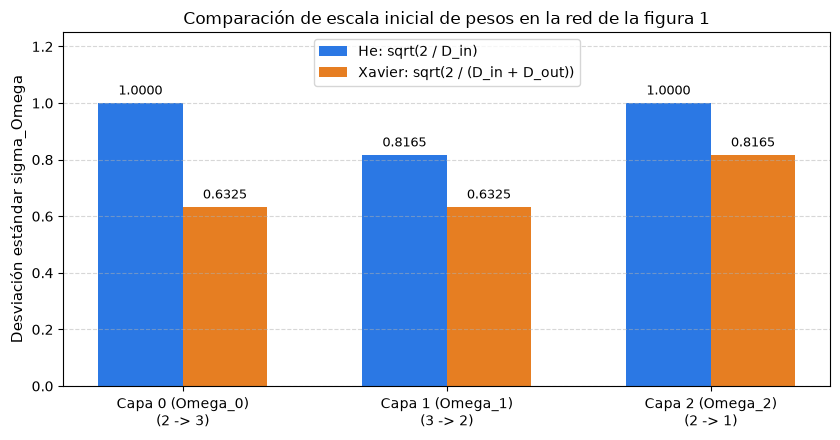

In [12]:
layers_fig1 = [
    ('Capa 0 (Omega_0)', 2, 3),
    ('Capa 1 (Omega_1)', 3, 2),
    ('Capa 2 (Omega_2)', 2, 1)
]

print('=== Cálculo numérico de sigma_Omega para la red de la figura 1 ===')
print(f"{'Capa':<20} {'D_in':<6} {'D_out':<7} {'Fórmula de He':<20} {'Fórmula de Xavier':<20}")
print('-' * 75)

names, s_he_list, s_xav_list = [], [], []
for name, d_in, d_out in layers_fig1:
    s_he = np.sqrt(2.0 / d_in)
    s_xav = np.sqrt(2.0 / (d_in + d_out))
    names.append(f"{name}\n({d_in} -> {d_out})")
    s_he_list.append(s_he)
    s_xav_list.append(s_xav)
    print(f"{name:<20} {d_in:<6} {d_out:<7} {f'sqrt(2/{d_in}) = {s_he:.4f}':<20} {f'sqrt(2/{d_in+d_out}) = {s_xav:.4f}':<20}")

x = np.arange(len(names))
width = 0.32

plt.figure(figsize=(8.5, 4.5))
rects1 = plt.bar(x - width/2, s_he_list, width, label='He: sqrt(2 / D_in)', color='#2b78e4')
rects2 = plt.bar(x + width/2, s_xav_list, width, label='Xavier: sqrt(2 / (D_in + D_out))', color='#e67e22')

plt.ylabel('Desviación estándar sigma_Omega', fontsize=11)
plt.title('Comparación de escala inicial de pesos en la red de la figura 1', fontsize=12)
plt.xticks(x, names, fontsize=10)
plt.ylim(0, 1.25)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

for rect in rects1:
    h = rect.get_height()
    plt.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9)

for rect in rects2:
    h = rect.get_height()
    plt.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

En el gráfico de barras se nota claramente la diferencia entre los dos métodos. En la capa 0 (que pasa de 2 a 3 neuronas), He da 1.0 porque solo mira las 2 entradas, mientras que Xavier baja a 0.6325 porque toma en cuenta también las 3 neuronas que salen. Ese valor más moderado en Xavier es justo lo que necesita la sigmoide para no saturarse. En la capa 1 ocurre lo mismo, y en la capa 2 He da 1.0 mientras que Xavier da 0.8165.

Para ver esto funcionando en la práctica, le pasamos 1000 datos sintéticos con la semilla fija 30326271 a la red que acabamos de programar y medimos la varianza de las señales que van saliendo en cada capa con ambos métodos.

In [13]:
# inicializamos la red de la figura 1 con ambos esquemas usando la semilla 30326271
seed = 30326271
w_he, b_he, _ = init_figure1_network('he', seed=seed)
w_xav, b_xav, _ = init_figure1_network('xavier', seed=seed)

# generamos 1000 entradas sintéticas 2D con la misma semilla
np.random.seed(seed)
X_test = np.random.normal(0.0, 1.0, size=(2, 1000))

# paso hacia adelante en ambas redes
out_he, (f0_he, f1_he, f2_he), (h1_he, h2_he) = forward_figure1(X_test, w_he, b_he)
out_xav, (f0_xav, f1_xav, f2_xav), (h1_xav, h2_xav) = forward_figure1(X_test, w_xav, b_xav)

print('=== Varianzas empíricas en la red de la figura 1 (1000 muestras) ===')
print(f'Capa 0 (f0):     He = {np.var(f0_he):.4f}  |  Xavier = {np.var(f0_xav):.4f}')
print(f'Capa 1 (f1):     He = {np.var(f1_he):.4f}  |  Xavier = {np.var(f1_xav):.4f}')
print(f'Capa 2 (salida): He = {np.var(f2_he):.4f}  |  Xavier = {np.var(f2_xav):.4f}')

=== Varianzas empíricas en la red de la figura 1 (1000 muestras) ===
Capa 0 (f0):     He = 2.8926  |  Xavier = 1.1570
Capa 1 (f1):     He = 0.5432  |  Xavier = 0.2868
Capa 2 (salida): He = 0.0024  |  Xavier = 0.0007


## Qué pasa cuando la red es profunda (20 capas)

En la red de la figura 1, como solo tiene dos capas ocultas, la diferencia entre He y Xavier se aprecia moderada. Pero en redes profundas cualquier desequilibrio en los pesos se multiplica capa tras capa hasta volverse inmanejable.

Para comprobar esto, armamos una red profunda de 20 capas con 80 neuronas por capa usando ReLU y comparamos tres esquemas con la semilla 30326271: una varianza reducida ($0.2 \times \text{He}$), la varianza adecuada de He ($2 / D$), y una varianza incrementada ($3.0 \times \text{He}$). Graficamos la varianza de las preactivaciones $f_k$ en función de la profundidad $k$ en escala logarítmica.

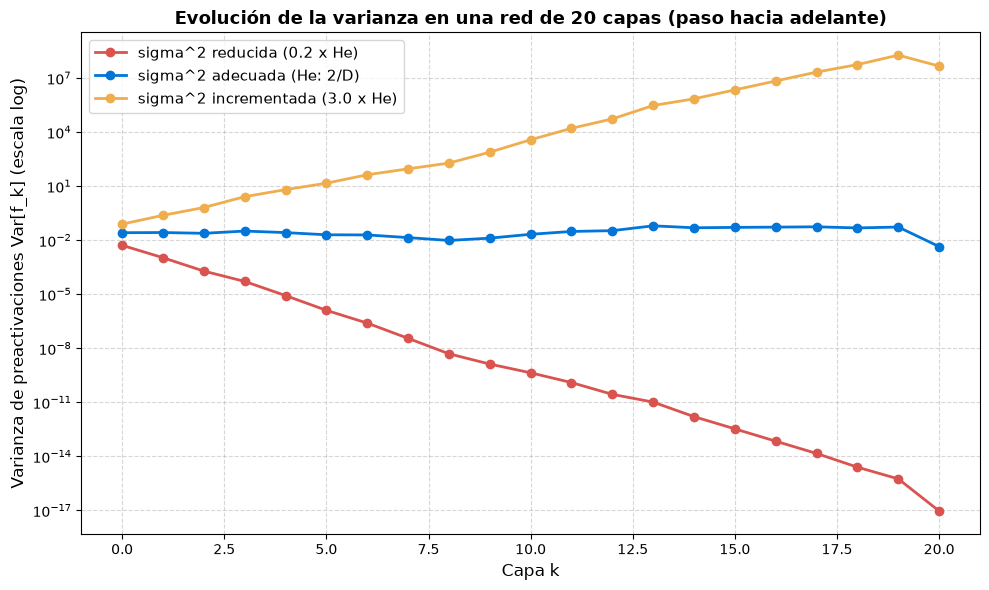

In [14]:
K_deep = 20
D_deep = 80
n_samples = 1000

sigma_sq_ideal = 2.0 / D_deep

schemes = {
    'sigma^2 reducida (0.2 x He)': 0.2 * sigma_sq_ideal,
    'sigma^2 adecuada (He: 2/D)': sigma_sq_ideal,
    'sigma^2 incrementada (3.0 x He)': 3.0 * sigma_sq_ideal
}

var_f_results = {}

for name, s_sq in schemes.items():
    np.random.seed(30326271)
    weights = [None] * (K_deep + 1)
    biases = [None] * (K_deep + 1)
    
    weights[0] = np.random.normal(size=(D_deep, 1)) * np.sqrt(s_sq)
    biases[0] = np.zeros((D_deep, 1))
    
    for l in range(1, K_deep):
        weights[l] = np.random.normal(size=(D_deep, D_deep)) * np.sqrt(s_sq)
        biases[l] = np.zeros((D_deep, 1))
        
    weights[K_deep] = np.random.normal(size=(1, D_deep)) * np.sqrt(s_sq)
    biases[K_deep] = np.zeros((1, 1))
    
    data_in = np.random.normal(size=(1, n_samples))
    h = data_in
    var_list = []
    
    for l in range(K_deep):
        f = biases[l] + np.matmul(weights[l], h)
        var_list.append(np.var(f))
        h = np.maximum(0, f)
        
    f_final = biases[K_deep] + np.matmul(weights[K_deep], h)
    var_list.append(np.var(f_final))
    
    var_f_results[name] = var_list

# gráfico de varianza de preactivaciones
fig, ax = plt.subplots(figsize=(10, 6))
layers = np.arange(K_deep + 1)

colors = {'sigma^2 reducida (0.2 x He)': '#d9534f',
          'sigma^2 adecuada (He: 2/D)': '#0275d8',
          'sigma^2 incrementada (3.0 x He)': '#f0ad4e'}

for name, var_list in var_f_results.items():
    ax.plot(layers, var_list, marker='o', linewidth=2, label=name, color=colors[name])

ax.set_yscale('log')
ax.set_xlabel('Capa k', fontsize=12)
ax.set_ylabel('Varianza de preactivaciones Var[f_k] (escala log)', fontsize=12)
ax.set_title('Evolución de la varianza en una red de 20 capas (paso hacia adelante)', fontsize=13, fontweight='bold')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

El gráfico muestra con total claridad el problema. Si usamos una varianza pequeña (línea roja), las preactivaciones se van apagando rápidamente hasta llegar a valores insignificantes del orden de $10^{-17}$ en la capa 20. Si usamos una varianza demasiado grande (línea naranja), los números explotan sin control superando $10^7$. En cambio, con la fórmula de He (línea azul), la varianza se mantiene estable alrededor de 0.02 a lo largo de toda la red.

Este comportamiento en el paso hacia adelante se traslada directamente al paso hacia atrás. Si las señales se apagan o explotan al avanzar, los gradientes hacen lo mismo al retroceder. Para comprobarlo, calculamos los gradientes con la función `backward_pass` y graficamos su desviación estándar a lo largo de las capas.

=== Desviación estándar de gradientes en el paso hacia atrás ===
sigma^2 reducida (0.2 x He):
  std gradiente capa 20 (salida): 1.3525e-01
  std gradiente capa 10:          7.6358e-05
  std gradiente capa 1 (entrada): 3.0698e-08
sigma^2 adecuada (He: 2/D):
  std gradiente capa 20 (salida): 2.7654e-01
  std gradiente capa 10:          4.8787e-01
  std gradiente capa 1 (entrada): 2.7411e-01
sigma^2 incrementada (3.0 x He):
  std gradiente capa 20 (salida): 4.5881e+03
  std gradiente capa 10:          1.9669e+06
  std gradiente capa 1 (entrada): 1.5504e+08


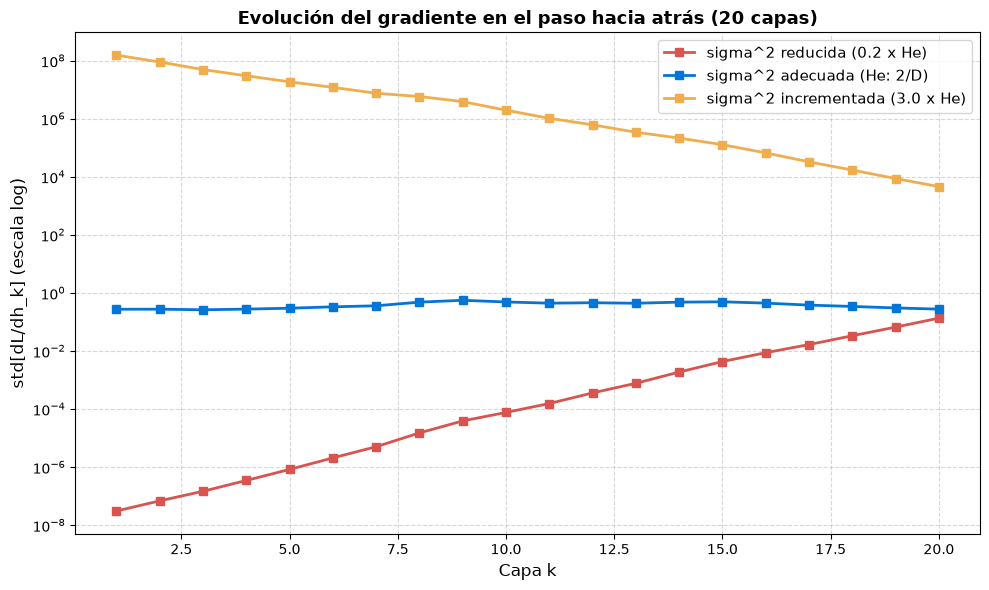

In [15]:
grad_results = {}

print('=== Desviación estándar de gradientes en el paso hacia atrás ===')
for name, s_sq in schemes.items():
    np.random.seed(30326271)
    w_deep = [None] * (K_deep + 1)
    b_deep = [None] * (K_deep + 1)
    
    w_deep[0] = np.random.normal(size=(D_deep, 1)) * np.sqrt(s_sq)
    b_deep[0] = np.zeros((D_deep, 1))
    for l in range(1, K_deep):
        w_deep[l] = np.random.normal(size=(D_deep, D_deep)) * np.sqrt(s_sq)
        b_deep[l] = np.zeros((D_deep, 1))
    w_deep[K_deep] = np.random.normal(size=(1, D_deep)) * np.sqrt(s_sq)
    b_deep[K_deep] = np.zeros((1, 1))
    
    # propagación hacia adelante
    x_test = np.random.normal(size=(1, 1))
    all_f = [None] * (K_deep + 1)
    all_h = [None] * (K_deep + 1)
    all_h[0] = x_test
    for l in range(K_deep):
        all_f[l] = b_deep[l] + np.matmul(w_deep[l], all_h[l])
        all_h[l+1] = np.maximum(0, all_f[l])
    all_f[K_deep] = b_deep[K_deep] + np.matmul(w_deep[K_deep], all_h[K_deep])
    
    y_test = np.array([[1.0]])
    
    # retropropagación
    all_dl_dweights, all_dl_dbiases, all_dl_dh, all_dl_df = backward_pass(w_deep, b_deep, all_f, all_h, y_test)
    
    grad_stds = [np.std(all_dl_dh[l]) for l in range(1, K_deep + 1)]
    grad_results[name] = grad_stds
    print(f'{name}:')
    print(f'  std gradiente capa 20 (salida): {grad_stds[-1]:.4e}')
    print(f'  std gradiente capa 10:          {grad_stds[9]:.4e}')
    print(f'  std gradiente capa 1 (entrada): {grad_stds[0]:.4e}')

# gráfico de desviación estándar de gradientes
fig, ax = plt.subplots(figsize=(10, 6))
layers_back = np.arange(1, K_deep + 1)

for name, grad_stds in grad_results.items():
    ax.plot(layers_back, grad_stds, marker='s', linewidth=2, label=name, color=colors[name])

ax.set_yscale('log')
ax.set_xlabel('Capa k', fontsize=12)
ax.set_ylabel('std[dL/dh_k] (escala log)', fontsize=12)
ax.set_title('Evolución del gradiente en el paso hacia atrás (20 capas)', fontsize=13, fontweight='bold')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

El gráfico del paso hacia atrás ilustra con total claridad los dos grandes problemas del entrenamiento profundo. Con la varianza pequeña (línea roja), los gradientes se van encogiendo al retroceder hacia las primeras capas hasta caer a $10^{-8}$. Esto es el fenómeno de desvanecimiento de gradiente (*vanishing gradient*): la señal de error prácticamente desaparece y las primeras capas no aprenden nada. Por el contrario, con la varianza grande (línea naranja), los gradientes explotan por encima de $10^8$ (*exploding gradient*), lo que provocaría desbordamientos numéricos y divergencia al entrenar. Únicamente con la inicialización adecuada de He (línea azul), los gradientes se conservan equilibrados en un rango estable (entre 0.27 y 0.49) a través de las 20 capas.

Los experimentos confirman de forma práctica la importancia crítica de la inicialización. En arquitecturas superficiales los desajustes de escala pueden parecer tolerables, pero en redes profundas de 20 o más capas se acumulan exponencialmente y determinan si el modelo puede aprender o no. Si los pesos son muy pequeños, los gradientes se desvanecen; si son muy grandes, explotan. Por lo tanto, es indispensable usar la regla correspondiente a cada activación: He para compensar las neuronas que inactiva ReLU, y Xavier para mantener equilibradas las señales en ambos sentidos con la sigmoide.